In [1]:
# =============================================================================
# CELL 1 — Mount Google Drive & set paths
# =============================================================================

from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import numpy as np
import pandas as pd
import os

# --- Paths -------------------------------------------------------------------
DATA_DIR: Path = Path("/content/drive/MyDrive/Sleep")
GLOBAL_META_PATH = DATA_DIR / "_global_meta.npz"
MANIFEST_PATH    = DATA_DIR / "cassette_manifest.csv"
SUBJ_SHARD_PATH  = DATA_DIR / "subject_to_shard.csv"

print("DATA_DIR exists :", DATA_DIR.exists())
print("\nFiles in Sleep/ :")
for p in sorted(DATA_DIR.iterdir()):
    size_mb = p.stat().st_size / 1e6
    print(f"  {p.name:35s}  {size_mb:10.1f} MB")

Mounted at /content/drive
DATA_DIR exists : True

Files in Sleep/ :
  _global_meta.npz                            0.0 MB
  cache                                       0.0 MB
  cassette_manifest.csv                       0.0 MB
  checkpoints                                 0.0 MB
  checkpoints_01_mcaf_eeg_5fold               0.0 MB
  checkpoints_02_liteeeg_fusion               0.0 MB
  checkpoints_02_liteeeg_fusion_single         0.0 MB
  checkpoints_MSDCA                           0.0 MB
  checkpoints_MSDCA_70_15_15                  0.0 MB
  checkpoints_cv                              0.0 MB
  checkpoints_tap_mcafnet                     0.0 MB
  checkpoints_tap_mcafnet_single              0.0 MB
  pacer_cv                                    0.0 MB
  shard_01.npz                              927.3 MB
  shard_02.npz                              918.8 MB
  shard_03.npz                              946.6 MB
  shard_04.npz                              871.2 MB
  shard_05.npz                

In [2]:
# =============================================================================
# CELL 2 — Discover all shard files
# =============================================================================

shard_paths = sorted(DATA_DIR.glob("shard_*.npz"))
print(f"Found {len(shard_paths)} shard files:")
for p in shard_paths:
    print(f"  {p.name}  ({p.stat().st_size / 1e9:.2f} GB)")

assert len(shard_paths) > 0, "No shard files found. Check the path."

Found 10 shard files:
  shard_01.npz  (0.93 GB)
  shard_02.npz  (0.92 GB)
  shard_03.npz  (0.95 GB)
  shard_04.npz  (0.87 GB)
  shard_05.npz  (0.92 GB)
  shard_06.npz  (0.89 GB)
  shard_07.npz  (0.94 GB)
  shard_08.npz  (0.87 GB)
  shard_09.npz  (0.86 GB)
  shard_10.npz  (0.70 GB)


In [3]:
# =============================================================================
# CELL 3 — Read and print global metadata
# =============================================================================

with np.load(GLOBAL_META_PATH, allow_pickle=False) as d:
    global_meta = {k: d[k] for k in d.files}

print("=" * 60)
print("GLOBAL METADATA — _global_meta.npz")
print("=" * 60)
for k, v in global_meta.items():
    if v.ndim == 0:
        print(f"  {k:20s}: {v.item()}")
    else:
        print(f"  {k:20s}: shape={v.shape}  dtype={v.dtype}")
        print(f"    {v.tolist()}")

# ---- Channel order is the key info we need ---------------------------------
channel_names = [str(x) for x in global_meta["channel_names"]]
print("\n" + "=" * 60)
print("X CHANNEL ORDER")
print("=" * 60)
for i, name in enumerate(channel_names):
    print(f"  X[:, {i}, :]  ->  {name}")

label_names = [str(x) for x in global_meta["label_names"]]
print("\nLabel encoding (y):")
for i, name in enumerate(label_names):
    print(f"  y == {i}  ->  {name}")

sfreq          = int(global_meta["sfreq"])
epoch_duration = int(global_meta["epoch_duration"])
print(f"\nSampling rate   : {sfreq} Hz")
print(f"Epoch duration  : {epoch_duration} s")
print(f"Samples / epoch : {sfreq * epoch_duration}")

GLOBAL METADATA — _global_meta.npz
  channel_names       : shape=(5,)  dtype=<U14
    ['EEG Fpz-Cz', 'EEG Pz-Oz', 'EOG horizontal', 'EMG submental', 'subject_id']
  label_names         : shape=(5,)  dtype=<U3
    ['W', 'N1', 'N2', 'N3', 'REM']
  sfreq               : 100
  epoch_duration      : 30

X CHANNEL ORDER
  X[:, 0, :]  ->  EEG Fpz-Cz
  X[:, 1, :]  ->  EEG Pz-Oz
  X[:, 2, :]  ->  EOG horizontal
  X[:, 3, :]  ->  EMG submental
  X[:, 4, :]  ->  subject_id

Label encoding (y):
  y == 0  ->  W
  y == 1  ->  N1
  y == 2  ->  N2
  y == 3  ->  N3
  y == 4  ->  REM

Sampling rate   : 100 Hz
Epoch duration  : 30 s
Samples / epoch : 3000


In [4]:
# =============================================================================
# CELL 4 — Read manifest and subject-shard mapping
# =============================================================================

manifest = pd.read_csv(MANIFEST_PATH)
subj_shard = pd.read_csv(SUBJ_SHARD_PATH)

print("=" * 60)
print("MANIFEST (cassette_manifest.csv)")
print("=" * 60)
print("Shape:", manifest.shape)
print("Columns:", manifest.columns.tolist())
print()
print(manifest.head(10).to_string(index=False))
print()
print("Shard distribution in manifest:")
print(manifest.groupby("shard_id").agg(
    n_recordings=("recording_key", "count"),
    n_subjects=("subject", "nunique"),
    n_epochs_kept=("n_epochs_kept", "sum"),
).to_string())

print("\n" + "=" * 60)
print("SUBJECT → SHARD MAPPING")
print("=" * 60)
print("Shape:", subj_shard.shape)
print(subj_shard.head(10).to_string(index=False))
print()
print("Subjects per shard:")
print(subj_shard.groupby("shard_id")["subject"].count().to_string())

MANIFEST (cassette_manifest.csv)
Shape: (153, 10)
Columns: ['recording_key', 'shard_id', 'subject', 'night', 'n_epochs_total', 'n_epochs_kept', 'n_w_total', 'n_w_kept', 'n_sleep_kept', 'missing_channels']

recording_key  shard_id  subject  night  n_epochs_total  n_epochs_kept  n_w_total  n_w_kept  n_sleep_kept  missing_channels
     SC4001E0         0        0      1            2650            773       1997       120           653               NaN
     SC4002E0         0        0      2            2830           1064       1885       120           944               NaN
     SC4251E0         0       25      1            2760            959       1921       120           839               NaN
     SC4252E0         0       25      2            2666            930       1855       120           810               NaN
     SC4281G0         0       28      1            2788           1054       1854       120           934               NaN
     SC4282G0         0       28      2           

In [5]:


# =============================================================================
# CELL 5 — Inspect one shard in detail
# =============================================================================

sample_shard_path = shard_paths[0]
print(f"Inspecting: {sample_shard_path.name}\n")

with np.load(sample_shard_path, allow_pickle=False) as d:
    print("Keys inside shard:", d.files)
    for k in d.files:
        arr = d[k]
        print(f"  {k:8s}: shape={arr.shape}  dtype={arr.dtype}")

    X_sample = d["X"]
    y_sample = d["y"]

print("\nX sample stats (per channel):")
for i, name in enumerate(channel_names):
    ch = X_sample[:, i, :]
    print(f"  ch {i} ({name:15s}): "
          f"min={ch.min():12.4f}  max={ch.max():12.4f}  "
          f"mean={ch.mean():10.4f}  std={ch.std():10.4f}  "
          f"nan={np.isnan(ch).sum()}")

print("\ny distribution:")
for i, name in enumerate(label_names):
    n = int((y_sample == i).sum())
    pct = 100 * n / len(y_sample)
    print(f"  {name:>4}: {n:>8,}  ({pct:5.2f}%)")

# Check subject_id is constant per row
subj_in_X = X_sample[:, channel_names.index("subject_id"), 0]
print(f"\nsubject_id in X (first 10 epochs): {subj_in_X[:10]}")
print(f"subject_id unique in this shard   : {np.unique(subj_in_X)}")

Inspecting: shard_01.npz

Keys inside shard: ['X', 'y']
  X       : shape=(15454, 5, 3000)  dtype=float32
  y       : shape=(15454,)  dtype=int8

X sample stats (per channel):
  ch 0 (EEG Fpz-Cz     ): min=     -0.0002  max=      0.0002  mean=   -0.0000  std=    0.0000  nan=0
  ch 1 (EEG Pz-Oz      ): min=     -0.0002  max=      0.0002  mean=    0.0000  std=    0.0000  nan=0
  ch 2 (EOG horizontal ): min=     -0.0006  max=      0.0006  mean=    0.0000  std=    0.0000  nan=0
  ch 3 (EMG submental  ): min=     -0.0000  max=      0.0000  mean=    0.0000  std=    0.0000  nan=0
  ch 4 (subject_id     ): min=      0.0000  max=     61.0000  mean=   37.6662  std=   18.9764  nan=0

y distribution:
     W:    1,920  (12.42%)
    N1:    2,069  (13.39%)
    N2:    6,684  (43.25%)
    N3:    1,906  (12.33%)
   REM:    2,875  (18.60%)

subject_id in X (first 10 epochs): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
subject_id unique in this shard   : [ 0. 25. 28. 33. 41. 51. 60. 61.]


In [6]:

# =============================================================================
# CELL 6 — Standard extraction: X_signals, y, subject_id
# =============================================================================

# Symbolic channel indices (from global_meta)
SIGNAL_CHANNEL_INDICES = [i for i, n in enumerate(channel_names)
                          if n != "subject_id"]
SUBJECT_ID_INDEX       = channel_names.index("subject_id") \
                          if "subject_id" in channel_names else None

print("Signal channel indices in X:", SIGNAL_CHANNEL_INDICES)
print("Subject_id index in X     :", SUBJECT_ID_INDEX)


def load_shard_xy(shard_path: Path) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Load a shard and return:
      X_signals : (n, 4, 3000) float32
      y         : (n,)         int8
      subject   : (n,)         int16
    """
    with np.load(shard_path, allow_pickle=False) as d:
        X_full = d["X"]
        y      = d["y"]

    X_signals = X_full[:, SIGNAL_CHANNEL_INDICES, :].astype(np.float32, copy=False)

    if SUBJECT_ID_INDEX is not None:
        subject = X_full[:, SUBJECT_ID_INDEX, 0].astype(np.int16)
    else:
        subject = np.zeros(len(y), dtype=np.int16)

    return X_signals, y, subject


# ---- Test on the first shard ------------------------------------------------
X_sample, y_sample, subj_sample = load_shard_xy(shard_paths[0])

print("\n" + "=" * 60)
print("EXTRACTED SHAPES")
print("=" * 60)
print(f"X_signals : {X_sample.shape}   dtype={X_sample.dtype}")
print(f"y         : {y_sample.shape}   dtype={y_sample.dtype}")
print(f"subject   : {subj_sample.shape}   dtype={subj_sample.dtype}")
print(f"\nX_signals per-epoch tensor (n, n_channels, n_samples)")
print(f"  n_channels = {X_sample.shape[1]}  -> {[channel_names[i] for i in SIGNAL_CHANNEL_INDICES]}")
print(f"  n_samples  = {X_sample.shape[2]}  -> {sfreq} Hz x {epoch_duration} s")

Signal channel indices in X: [0, 1, 2, 3]
Subject_id index in X     : 4

EXTRACTED SHAPES
X_signals : (15454, 4, 3000)   dtype=float32
y         : (15454,)   dtype=int8
subject   : (15454,)   dtype=int16

X_signals per-epoch tensor (n, n_channels, n_samples)
  n_channels = 4  -> ['EEG Fpz-Cz', 'EEG Pz-Oz', 'EOG horizontal', 'EMG submental']
  n_samples  = 3000  -> 100 Hz x 30 s


In [7]:
# =============================================================================
# CELL 7a — Load subject_id and y from all shards (memory-safe)
# =============================================================================

import numpy as np
import pandas as pd
from pathlib import Path

SUBJECT_ID_INDEX = channel_names.index("subject_id")   # = 4
N_CLASSES        = len(label_names)                    # = 5

subject_chunks: list[np.ndarray] = []
y_chunks: list[np.ndarray] = []

print("Scanning shards...\n")
for sp in shard_paths:
    with np.load(sp, allow_pickle=False) as d:
        y = d["y"].astype(np.int8)
        X = d["X"]
        subject = X[:, SUBJECT_ID_INDEX, 0].astype(np.int16)
        del X
    subject_chunks.append(subject)
    y_chunks.append(y)
    print(f"  {sp.name}: {len(y):>7,} epochs | "
          f"{len(np.unique(subject)):>3d} subjects")

subject_all = np.concatenate(subject_chunks).astype(np.int16)
y_all       = np.concatenate(y_chunks).astype(np.int8)
del subject_chunks, y_chunks

print(f"\nTotal epochs   : {len(y_all):,}")
print(f"Total subjects : {len(np.unique(subject_all))}")
print(f"Labels         : {label_names}")

Scanning shards...

  shard_01.npz:  15,454 epochs |   8 subjects
  shard_02.npz:  15,313 epochs |   8 subjects
  shard_03.npz:  15,776 epochs |   8 subjects
  shard_04.npz:  14,519 epochs |   8 subjects
  shard_05.npz:  15,404 epochs |   8 subjects
  shard_06.npz:  14,890 epochs |   8 subjects
  shard_07.npz:  15,736 epochs |   8 subjects
  shard_08.npz:  14,518 epochs |   8 subjects
  shard_09.npz:  14,305 epochs |   7 subjects
  shard_10.npz:  11,681 epochs |   7 subjects

Total epochs   : 147,596
Total subjects : 78
Labels         : ['W', 'N1', 'N2', 'N3', 'REM']


In [8]:
# =============================================================================
# CELL 7b — Per-subject class counts
# =============================================================================

subjects_sorted = sorted(np.unique(subject_all).tolist())
n_subjects = len(subjects_sorted)

counts_table = np.zeros((n_subjects, N_CLASSES), dtype=int)
for i, s in enumerate(subjects_sorted):
    counts_table[i] = np.bincount(
        y_all[subject_all == s], minlength=N_CLASSES
    )

df_counts = pd.DataFrame(counts_table, index=subjects_sorted, columns=label_names)
df_counts.index.name = "subject"
df_counts["TOTAL"] = df_counts[label_names].sum(axis=1)

print("=" * 100)
print("PER-SUBJECT CLASS COUNTS")
print("=" * 100)
print(df_counts.to_string())

print("\n" + "=" * 70)
print("SUMMARY")
print("=" * 70)
summary = pd.DataFrame({
    "total_epochs":    df_counts[label_names].sum(axis=0),
    "mean_per_subj":   df_counts[label_names].mean(axis=0).round(1),
    "median_per_subj": df_counts[label_names].median(axis=0),
    "min_per_subj":    df_counts[label_names].min(axis=0),
    "max_per_subj":    df_counts[label_names].max(axis=0),
    "subj_with_zero":  (df_counts[label_names] == 0).sum(axis=0),
    "subj_below_30":   (df_counts[label_names] < 30).sum(axis=0),
})
print(summary.to_string())

# --- Subjects with a missing class ------------------------------------------
print("\n" + "=" * 70)
print("SUBJECTS MISSING AT LEAST ONE CLASS")
print("=" * 70)
missing_any = []
for s in subjects_sorted:
    miss = [c for c in label_names if df_counts.loc[s, c] == 0]
    if miss:
        missing_any.append((s, miss))
        print(f"  subject {s:>3d}: {miss}")
if not missing_any:
    print("  All subjects have every class.")

PER-SUBJECT CLASS COUNTS
           W   N1    N2   N3  REM  TOTAL
subject                                 
0        240  117   623  517  340   1837
1        240  201  1222  201  346   2210
2        240  278   947  214  342   2021
3        240  106   885  188  408   1827
4        240  303  1134  147  466   2290
5        240  158   833  249  248   1728
6        240  146   824  265  289   1764
7        240  173   795  384  366   1958
8        240  107   591  632  391   1961
9        240  100  1073  277  497   2187
10       240  182  1278   31  406   2137
11       240   31   898  240  309   1718
12       240  169   750  187  457   1803
13       120   57   497  147  172    993
14       240   56   790  296  446   1828
15       240   88   792  355  500   1975
16       240   97   907  293  455   1992
17       240   65  1015  403  427   2150
18       240  180   678  507  234   1839
19       240  190  1267  170  618   2485
20       240  159  1018    4  384   1805
21       240  193   929   92  23

In [9]:


# =============================================================================
# CELL 7c — Build pools for train / val / test
# =============================================================================

# Every val/test subject must have at least this many epochs per class.
MIN_PER_CLASS_FOR_EVAL = 20

eligible_for_eval = [
    int(s) for s in subjects_sorted
    if all(df_counts.loc[s, c] >= MIN_PER_CLASS_FOR_EVAL for c in label_names)
]

print("=" * 70)
print("ELIGIBLE POOL FOR VAL / TEST")
print("=" * 70)
print(f"Threshold per class : >= {MIN_PER_CLASS_FOR_EVAL} epochs")
print(f"Eligible subjects   : {len(eligible_for_eval)} / {n_subjects}")
print(f"  {eligible_for_eval}")

# -----------------------------------------------------------------------------
# Split sizes
# -----------------------------------------------------------------------------
N_TOTAL = n_subjects                          # 78
N_VAL   = int(round(0.10 * N_TOTAL))          # 8
N_TEST  = int(round(0.10 * N_TOTAL))          # 8
N_TRAIN = N_TOTAL - N_VAL - N_TEST            # 62

print(f"\nTarget split sizes:")
print(f"  Train : {N_TRAIN}")
print(f"  Val   : {N_VAL}")
print(f"  Test  : {N_TEST}")

assert len(eligible_for_eval) >= N_VAL + N_TEST, (
    f"Not enough eligible subjects ({len(eligible_for_eval)}) "
    f"for val+test ({N_VAL + N_TEST})"
)

ELIGIBLE POOL FOR VAL / TEST
Threshold per class : >= 20 epochs
Eligible subjects   : 62 / 78
  [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 21, 22, 24, 25, 26, 27, 28, 29, 30, 31, 35, 36, 38, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 53, 54, 55, 56, 57, 59, 60, 61, 63, 65, 66, 67, 70, 75, 76, 77, 81, 82]

Target split sizes:
  Train : 62
  Val   : 8
  Test  : 8


In [10]:
# =============================================================================
# CELL 7d — Search for the best subject-level split (80/10/10)
# =============================================================================

RANDOM_SEED       = 42
N_SEARCH_TRIALS   = 10000 # Increased number of trials

rng = np.random.default_rng(RANDOM_SEED)

# --- helper: class distribution over a set of subjects ----------------------
def class_dist_for(subj_set):
    mask = np.isin(subject_all, list(subj_set))
    return np.bincount(y_all[mask], minlength=N_CLASSES)

# --- overall distribution (target) ------------------------------------------
overall_counts = np.bincount(y_all, minlength=N_CLASSES)
overall_pct    = overall_counts / overall_counts.sum()

best = None
best_score = np.inf

for trial in range(N_SEARCH_TRIALS):
    pool = np.array(eligible_for_eval)
    rng.shuffle(pool)

    val_set  = set(pool[:N_VAL].tolist())
    test_set = set(pool[N_VAL : N_VAL + N_TEST].tolist())

    # --- ensure every class is present with at least MIN_PER_CLASS epochs ---
    val_dist  = class_dist_for(val_set)
    test_dist = class_dist_for(test_set)
    if (val_dist  < MIN_PER_CLASS_FOR_EVAL).any(): continue
    if (test_dist < MIN_PER_CLASS_FOR_EVAL).any(): continue

    # --- score: sum of absolute % differences from overall -------------------
    val_pct  = val_dist  / val_dist.sum()
    test_pct = test_dist / test_dist.sum()
    score = (
        np.abs(val_pct  - overall_pct).sum()
      + np.abs(test_pct - overall_pct).sum()
    )

    if score < best_score:
        best_score  = score
        best_val    = val_set
        best_test   = test_set
        best = True # Set best to True if a better score is found

if best is None:
    raise RuntimeError("Could not find a split satisfying the class-coverage "
                       "constraint. Try lowering MIN_PER_CLASS_FOR_EVAL.")

val_subjects  = best_val
test_subjects = best_test
train_subjects = set(subjects_sorted) - val_subjects - test_subjects

print("=" * 70)
print(f"BEST SPLIT FOUND (score = {best_score:.4f})")
print("=" * 70)
print(f"Train ({len(train_subjects):>2d} subjects): {sorted(train_subjects)}")
print(f"Val   ({len(val_subjects):>2d} subjects): {sorted(val_subjects)}")
print(f"Test  ({len(test_subjects):>2d} subjects): {sorted(test_subjects)}")

# --- sanity -----------------------------------------------------------------
assert train_subjects.isdisjoint(val_subjects)
assert train_subjects.isdisjoint(test_subjects)
assert val_subjects.isdisjoint(test_subjects)
print("\n✓ No subject overlap between splits.")

BEST SPLIT FOUND (score = 0.0392)
Train (62 subjects): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 16, 17, 19, 20, 21, 22, 23, 25, 26, 27, 29, 30, 32, 33, 34, 35, 36, 37, 38, 41, 42, 43, 44, 45, 46, 48, 49, 51, 52, 53, 55, 56, 58, 59, 60, 61, 62, 64, 65, 66, 71, 72, 73, 74, 76, 80, 81, 82]
Val   ( 8 subjects): [12, 28, 31, 47, 57, 70, 75, 77]
Test  ( 8 subjects): [15, 18, 24, 40, 50, 54, 63, 67]

✓ No subject overlap between splits.


In [11]:
# =============================================================================
# CELL 7e — Report class distribution in each split (FIXED)
# =============================================================================

def _n_epochs(subj_set):
    return int(np.isin(subject_all, list(subj_set)).sum())

print("=" * 70)
print("EPOCH COUNTS PER SPLIT")
print("=" * 70)
print(f"  Train : {_n_epochs(train_subjects):>8,}")
print(f"  Val   : {_n_epochs(val_subjects):>8,}")
print(f"  Test  : {_n_epochs(test_subjects):>8,}")
print(f"  Total : {_n_epochs(train_subjects | val_subjects | test_subjects):>8,}")

# ---- Raw counts per split ---------------------------------------------------
train_dist = class_dist_for(train_subjects)
val_dist   = class_dist_for(val_subjects)
test_dist  = class_dist_for(test_subjects)

dist_df = pd.DataFrame(
    {"train": train_dist, "val": val_dist, "test": test_dist},
    index=label_names,
)
dist_df.loc["TOTAL"] = dist_df.sum(axis=0)

print("\nClass counts per split:")
print(dist_df.to_string())

# ---- Percent per split (columns sum to 100) ---------------------------------
pct_df = (dist_df.drop("TOTAL").div(dist_df.loc["TOTAL"], axis=1) * 100).round(2)

print("\nClass distribution per split (%):")
print(pct_df.to_string())

# ---- Overall distribution (across all splits) -------------------------------
overall_counts  = dist_df.drop("TOTAL").sum(axis=1)          # Series indexed by class
overall_pct_df  = (overall_counts / overall_counts.sum() * 100).round(2)
overall_pct_df.name = "overall"

print("\nOverall distribution (%):")
print(overall_pct_df.to_string())

# ---- Deviation from overall, per split --------------------------------------
dev = pct_df.sub(overall_pct_df, axis=0).round(2)

print("\nDeviation from overall (%):")
print(dev.to_string())

# ---- Max absolute deviation summary -----------------------------------------
print("\nMax |deviation| per split:")
print(dev.abs().max().round(2).to_string())

EPOCH COUNTS PER SPLIT
  Train :  117,654
  Val   :   14,800
  Test  :   15,142
  Total :  147,596

Class counts per split:
        train    val   test
W       14260   1888   1920
N1      17122   2166   2234
N2      55116   6926   7090
N3      10319   1423   1297
REM     20837   2397   2601
TOTAL  117654  14800  15142

Class distribution per split (%):
     train    val   test
W    12.12  12.76  12.68
N1   14.55  14.64  14.75
N2   46.85  46.80  46.82
N3    8.77   9.61   8.57
REM  17.71  16.20  17.18

Overall distribution (%):
W      12.24
N1     14.58
N2     46.84
N3      8.83
REM    17.50

Deviation from overall (%):
     train   val  test
W    -0.12  0.52  0.44
N1   -0.03  0.06  0.17
N2    0.01 -0.04 -0.02
N3   -0.06  0.78 -0.26
REM   0.21 -1.30 -0.32

Max |deviation| per split:
train    0.21
val      1.30
test     0.44


## Second Phase

In [12]:
# =============================================================================
# CELL 1 — Imports and global configuration
# =============================================================================

import os, json, math, random, gc, time
from pathlib import Path
from typing import Iterator, Optional

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Sampler

from google.colab import drive
drive.mount('/content/drive')

# -----------------------------------------------------------------------------
# Paths
# -----------------------------------------------------------------------------
DATA_DIR   = Path("/content/drive/MyDrive/Sleep")
SPLIT_PATH = DATA_DIR / "splits.json"
CKPT_DIR   = DATA_DIR / "checkpoints"
CKPT_DIR.mkdir(parents=True, exist_ok=True)

# -----------------------------------------------------------------------------
# Reproducibility
# -----------------------------------------------------------------------------
SEED = 42
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
set_seed(SEED)

# -----------------------------------------------------------------------------
# Signal / dataset constants
# -----------------------------------------------------------------------------
SFREQ           = 100                # Hz
EPOCH_SEC       = 30
SAMPLES_PER_EPOCH = SFREQ * EPOCH_SEC  # 3000
N_CLASSES       = 5
CLASS_NAMES     = ["W", "N1", "N2", "N3", "REM"]

# Channels kept in X — order must be [Fpz-Cz, Pz-Oz, EOG]
KEEP_CHANNELS   = ["EEG Fpz-Cz", "EEG Pz-Oz", "EOG horizontal"]
N_CHANNELS      = len(KEEP_CHANNELS)

# -----------------------------------------------------------------------------
# STFT parameters (from paper §2.5.2)
# -----------------------------------------------------------------------------
STFT_NPERSEG    = 256         # 256-point STFT
STFT_NOVERLAP   = 128         # 50 % overlap of 2 s window (256 = 2 s × 100 Hz → hop = 128)
STFT_HOP        = STFT_NPERSEG - STFT_NOVERLAP  # 128 samples
STFT_FREQ_BINS  = STFT_NPERSEG // 2 + 1         # 129 → keep 128 (drop Nyquist)
STFT_TIME_BINS  = 29          # (3000 - 256) / 128 + 1 = 22.4 → 29?
# We'll compute STFT_TIME_BINS dynamically from the actual signal.

# -----------------------------------------------------------------------------
# Model hyper-parameters (from paper §2.5.2)
# -----------------------------------------------------------------------------
FEATURE_DIM     = 128         # D
N_ATTN_HEADS    = 4           # H
N_ATTN_LAYERS   = 2           # NA
CONV_KERNEL     = 3           # NC
CONV_GROUPS     = 3           # depth-wise separable groups
DROPout         = 0.5         # dropout rate
FC_HIDDEN       = 512         # HF

# -----------------------------------------------------------------------------
# Training hyper-parameters
# -----------------------------------------------------------------------------
BATCH_SIZE      = 128
NUM_EPOCHS      = 30
LR              = 1e-3
WEIGHT_DECAY    = 1e-2
WARMUP_EPOCHS   = 5
LABEL_SMOOTHING = 0.1
GRAD_CLIP       = 1.0
NUM_WORKERS     = 0           # Colab: keep 0 to avoid pickling issues
PIN_MEMORY      = True
DEVICE          = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device: {DEVICE}")
print(f"Feature dim D={FEATURE_DIM}, heads H={N_ATTN_HEADS}, layers NA={N_ATTN_LAYERS}")
print(f"Batch size: {BATCH_SIZE}, LR: {LR}, Epochs: {NUM_EPOCHS}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda
Feature dim D=128, heads H=4, layers NA=2
Batch size: 128, LR: 0.001, Epochs: 30


In [13]:
# =============================================================================
# CELL 2 — Subject-wise split 70/15/15 with leakage checks
# =============================================================================

from sklearn.model_selection import GroupShuffleSplit

# ---- Load manifest to know which subjects exist -----------------------------
manifest = pd.read_csv(DATA_DIR / "cassette_manifest.csv")
all_subjects = sorted(manifest["subject"].unique().tolist())
n_subjects = len(all_subjects)
print(f"Total subjects: {n_subjects}")

# ---- Target counts ----------------------------------------------------------
N_TRAIN = int(round(0.70 * n_subjects))   # ≈55
N_VAL   = int(round(0.15 * n_subjects))   # ≈12
N_TEST  = n_subjects - N_TRAIN - N_VAL    # ≈11
print(f"Target: train={N_TRAIN}, val={N_VAL}, test={N_TEST}")

# ---- Deterministic subject-level split --------------------------------------
rng = np.random.default_rng(SEED)
subjects_perm = rng.permutation(all_subjects)

train_subjects = set(subjects_perm[:N_TRAIN].tolist())
val_subjects   = set(subjects_perm[N_TRAIN:N_TRAIN + N_VAL].tolist())
test_subjects  = set(subjects_perm[N_TRAIN + N_VAL:].tolist())

# ---- Leakage checks ---------------------------------------------------------
assert len(train_subjects & val_subjects) == 0,  "Leak train ↔ val"
assert len(train_subjects & test_subjects) == 0, "Leak train ↔ test"
assert len(val_subjects & test_subjects) == 0,   "Leak val ↔ test"
assert len(train_subjects | val_subjects | test_subjects) == n_subjects

print("✓ No subject overlap between splits.")

# ---- Save splits.json -------------------------------------------------------
splits = {
    "train_subjects":      sorted(train_subjects),
    "validation_subjects": sorted(val_subjects),
    "test_subjects":       sorted(test_subjects),
    "seed": SEED,
    "n_subjects": n_subjects,
}
with open(SPLIT_PATH, "w") as f:
    json.dump(splits, f, indent=2)
print(f"✓ Saved splits to {SPLIT_PATH}")

# ---- Class distribution per split (subject-wise) ----------------------------
def _class_dist(subj_set, manifest_df):
    sub = manifest_df[manifest_df["subject"].isin(subj_set)]
    return np.array([sub[f"n_{c}"].sum() for c in CLASS_NAMES])

# Compute from manifest columns n_W, n_N1, n_N2, n_N3, n_REM
# (These columns are assumed present; if not, we'll compute from shards.)
print("\nSubject-wise class distribution (from manifest):")

Total subjects: 78
Target: train=55, val=12, test=11
✓ No subject overlap between splits.
✓ Saved splits to /content/drive/MyDrive/Sleep/splits.json

Subject-wise class distribution (from manifest):


In [14]:
# =============================================================================
# CELL 3 — Compute per-subject class counts (streaming, memory-safe)
# =============================================================================

SUBJECT_IDX_IN_X = 4  # index of subject_id in the raw shard X

# Load all subject & y arrays from shards (only those two, memory-safe)
subject_all_list, y_all_list = [], []
for sp in sorted(DATA_DIR.glob("shard_*.npz")):
    with np.load(sp, allow_pickle=False) as d:
        y = d["y"].astype(np.int8)
        subj = d["X"][:, SUBJECT_IDX_IN_X, 0].astype(np.int16)
    subject_all_list.append(subj)
    y_all_list.append(y)

subject_all = np.concatenate(subject_all_list)
y_all       = np.concatenate(y_all_list)
del subject_all_list, y_all_list
print(f"Total epochs loaded: {len(y_all):,}")

# Build per-subject counts
subjects_sorted = sorted(np.unique(subject_all).tolist())
counts = np.zeros((len(subjects_sorted), N_CLASSES), dtype=int)
for i, s in enumerate(subjects_sorted):
    counts[i] = np.bincount(y_all[subject_all == s], minlength=N_CLASSES)

df_counts = pd.DataFrame(counts, index=subjects_sorted, columns=CLASS_NAMES)
df_counts.index.name = "subject"
df_counts["TOTAL"] = df_counts[CLASS_NAMES].sum(axis=1)
print(df_counts.to_string())

# ---- Class distribution per split ------------------------------------------
def class_dist_for_subjects(subj_set):
    mask = np.isin(subject_all, list(subj_set))
    return np.bincount(y_all[mask], minlength=N_CLASSES)

train_dist = class_dist_for_subjects(train_subjects)
val_dist   = class_dist_for_subjects(val_subjects)
test_dist  = class_dist_for_subjects(test_subjects)

dist_df = pd.DataFrame(
    {"train": train_dist, "val": val_dist, "test": test_dist},
    index=CLASS_NAMES,
)
dist_df.loc["TOTAL"] = dist_df.sum(axis=0)

print("\nClass counts per split:")
print(dist_df.to_string())
pct_df = (dist_df.drop("TOTAL") / dist_df.loc["TOTAL"] * 100).round(2)
print("\nClass distribution (%):")
print(pct_df.to_string())

Total epochs loaded: 147,596
           W   N1    N2   N3  REM  TOTAL
subject                                 
0        240  117   623  517  340   1837
1        240  201  1222  201  346   2210
2        240  278   947  214  342   2021
3        240  106   885  188  408   1827
4        240  303  1134  147  466   2290
5        240  158   833  249  248   1728
6        240  146   824  265  289   1764
7        240  173   795  384  366   1958
8        240  107   591  632  391   1961
9        240  100  1073  277  497   2187
10       240  182  1278   31  406   2137
11       240   31   898  240  309   1718
12       240  169   750  187  457   1803
13       120   57   497  147  172    993
14       240   56   790  296  446   1828
15       240   88   792  355  500   1975
16       240   97   907  293  455   1992
17       240   65  1015  403  427   2150
18       240  180   678  507  234   1839
19       240  190  1267  170  618   2485
20       240  159  1018    4  384   1805
21       240  193   929   92

In [15]:
# =============================================================================
# CELL 4 — STFT time-frequency representation
# =============================================================================

def compute_stft_representation(
    signal: np.ndarray,          # (C, T)  float32, C=3 channels
    fs: int = SFREQ,
    nperseg: int = STFT_NPERSEG,
    noverlap: int = STFT_NOVERLAP,
) -> np.ndarray:
    """
    Compute log-power STFT for each channel.
    Returns array of shape (C, T_freq, F) where:
        T_freq = number of time frames
        F      = frequency bins (nperseg // 2 + 1)
    Values are log-power (dB-ish).
    """
    C = signal.shape[0]
    hop = nperseg - noverlap
    n_freq = nperseg // 2 + 1

    # Use scipy for STFT (vectorized across channels)
    from scipy.signal import stft

    specs = []
    for c in range(C):
        f, t, Z = stft(
            signal[c],
            fs=fs,
            window="hamming",
            nperseg=nperseg,
            noverlap=noverlap,
            boundary=None,
            padded=False,
        )
        # Z shape: (n_freq, n_time)
        power = np.abs(Z) ** 2
        log_power = np.log10(power + 1e-10)
        specs.append(log_power)

    # Stack → (C, n_freq, n_time), then transpose to (C, n_time, n_freq)
    out = np.stack(specs, axis=0)                 # (C, n_freq, n_time)
    out = np.transpose(out, (0, 2, 1))            # (C, n_time, n_freq)
    return out.astype(np.float32)


def compute_stft_batch(
    signals: np.ndarray,          # (B, C, T)
) -> np.ndarray:
    """Vectorized STFT over a batch. Returns (B, C, T_freq, F)."""
    B = signals.shape[0]
    outs = [compute_stft_representation(signals[i]) for i in range(B)]
    return np.stack(outs, axis=0)

In [16]:
# =============================================================================
# CELL 4b — Compute the actual STFT output shape for our data
# =============================================================================

dummy = np.zeros((N_CHANNELS, SAMPLES_PER_EPOCH), dtype=np.float32)
dummy_stft = compute_stft_representation(dummy)
print(f"STFT output shape: {dummy_stft.shape}  (C, T_freq, F)")
T_FREQ = dummy_stft.shape[1]
F_BINS = dummy_stft.shape[2]
print(f"T_freq = {T_FREQ}, F = {F_BINS}")

# Paper: T=29, F=128. Our T_freq differs → we'll let the model adapt.

STFT output shape: (3, 22, 129)  (C, T_freq, F)
T_freq = 22, F = 129


In [17]:
# =============================================================================
# CELL 5 — PyTorch Dataset that loads shards on demand
# =============================================================================

class SleepEDFDataset(Dataset):
    """
    Loads all epochs belonging to a given set of subjects.
    Since shards are large (≈900 MB each), we load them once and keep
    the relevant slices in memory.

    We store the STFT representation (not raw signal) to save RAM.
    If RAM is tight, set `precompute_stft=False` and compute STFT on-the-fly.
    """

    def __init__(
        self,
        data_dir: Path,
        subject_set: set,
        *,
        precompute_stft: bool = True,
        normalize: bool = True,
        norm_stats: Optional[dict] = None,   # dict with 'mean' and 'std' per channel
    ):
        super().__init__()
        self.data_dir = Path(data_dir)
        self.subject_set = set(subject_set)
        self.precompute_stft = precompute_stft
        self.normalize = normalize
        self.norm_stats = norm_stats

        self._signals: list[np.ndarray] = []   # each: (n_i, C, 3000)
        self._stfts:   list[np.ndarray] = []   # each: (n_i, C, T_freq, F)
        self._labels:  list[np.ndarray] = []   # each: (n_i,)
        self._subjects: list[np.ndarray] = []  # each: (n_i,)

        self._load()

    def _load(self):
        for sp in sorted(self.data_dir.glob("shard_*.npz")):
            with np.load(sp, allow_pickle=False) as d:
                X = d["X"]                              # (n, 5, 3000)
                y = d["y"].astype(np.int64)              # (n,)
                subj = X[:, SUBJECT_IDX_IN_X, 0].astype(np.int16)

            mask = np.isin(subj, list(self.subject_set))
            if not mask.any():
                continue

            X_sel = X[mask][:, [0, 1, 2], :]             # keep 3 channels
            y_sel = y[mask]
            subj_sel = subj[mask]

            if self.precompute_stft:
                stft_sel = compute_stft_batch(X_sel)     # (n, C, T_freq, F)
                self._stfts.append(stft_sel)
            else:
                self._signals.append(X_sel)

            self._labels.append(y_sel)
            self._subjects.append(subj_sel)

        if self.precompute_stft:
            self._stfts = [np.concatenate(self._stfts, axis=0)]
        else:
            self._signals = [np.concatenate(self._signals, axis=0)]

        self._labels   = [np.concatenate(self._labels, axis=0)]
        self._subjects = [np.concatenate(self._subjects, axis=0)]

        if self.precompute_stft:
            self.n = self._stfts[0].shape[0]
        else:
            self.n = self._signals[0].shape[0]

        print(f"  loaded {self.n} epochs for subjects {sorted(self.subject_set)[:5]}...")

        # ---- Compute normalization stats if not provided --------------------
        if self.normalize and self.norm_stats is None:
            self._compute_norm_stats()

    def _compute_norm_stats(self):
        """Compute per-channel mean/std from the STFT features."""
        # Concatenate all STFT tensors: (n, C, T, F)
        arr = self._stfts[0]                       # (n, C, T, F)
        # mean/std over (n, T, F) → per channel
        mean = arr.mean(axis=(0, 2, 3))            # (C,)
        std  = arr.std(axis=(0, 2, 3)) + 1e-8       # (C,)
        self.norm_stats = {"mean": mean.astype(np.float32),
                           "std":  std.astype(np.float32)}

    def set_norm_stats(self, mean, std):
        self.norm_stats = {"mean": np.asarray(mean, dtype=np.float32),
                           "std":  np.asarray(std, dtype=np.float32)}

    def __len__(self):
        return self.n

    def __getitem__(self, idx: int):
        if self.precompute_stft:
            x = self._stfts[0][idx]                  # (C, T, F)
        else:
            sig = self._signals[0][idx]              # (C, 3000)
            x = compute_stft_representation(sig)      # (C, T, F)

        if self.normalize and self.norm_stats is not None:
            x = (x - self.norm_stats["mean"][:, None, None]) / \
                self.norm_stats["std"][:, None, None]

        y = self._labels[0][idx]
        subj = self._subjects[0][idx]
        return torch.from_numpy(x).float(), int(y), int(subj)

In [18]:
# =============================================================================
# CELL 6 — Instantiate datasets and dataloaders
# =============================================================================

print("Building train dataset...")
train_ds = SleepEDFDataset(DATA_DIR, train_subjects, precompute_stft=True)

print("\nBuilding validation dataset...")
val_ds = SleepEDFDataset(DATA_DIR, val_subjects, precompute_stft=True,
                         normalize=True, norm_stats=train_ds.norm_stats)

print("\nBuilding test dataset...")
test_ds = SleepEDFDataset(DATA_DIR, test_subjects, precompute_stft=True,
                          normalize=True, norm_stats=train_ds.norm_stats)

# ---- DataLoaders ------------------------------------------------------------
train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
)

print(f"\nTrain batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print(f"Test batches  : {len(test_loader)}")

# ---- Smoke test -------------------------------------------------------------
xb, yb, sb = next(iter(train_loader))
print(f"\nSample batch: x={xb.shape}, y={yb.shape}, subj={sb.shape}")
print(f"x dtype: {xb.dtype}, x range: [{xb.min():.3f}, {xb.max():.3f}]")

Building train dataset...
  loaded 105063 epochs for subjects [0, 1, 2, 3, 4]...

Building validation dataset...
  loaded 22686 epochs for subjects [6, 11, 19, 22, 38]...

Building test dataset...
  loaded 19847 epochs for subjects [8, 12, 13, 14, 35]...

Train batches : 821
Val batches   : 178
Test batches  : 156

Sample batch: x=torch.Size([128, 3, 22, 129]), y=torch.Size([128]), subj=torch.Size([128])
x dtype: torch.float32, x range: [-0.035, 57.375]


In [19]:
# =============================================================================
# CELL 7 — MCAF-Net: Multi-Channel Attention Fusion Network
# =============================================================================
# Faithful implementation of:
#   Xu et al., "MCAF-Net: Multi-Channel Temporal Cross-Attention Network with
#   Dynamic Gating for Sleep Stage Classification", Sensors 2025, 25(14), 4251.
#
# Modules:
#   1. TemporalConv  — per-channel temporal feature extraction (two 1D convs)
#   2. MCAF          — dynamic gated multi-head cross-channel attention
#   3. Classification — two fully-connected layers
#
# Implementation details flagged as "ADAPTED" are not fully specified in the
# paper and required engineering decisions.
# =============================================================================


class TemporalConv(nn.Module):
    """
    Per-channel temporal feature extraction (paper §2.2).
    Input : (B, C, T, F)  →  transposed to (B, C, F, T)  →  1D conv over T
    Output: (B, C, T, D) where D = FEATURE_DIM
    """
    def __init__(self, in_dim: int, out_dim: int, kernel_size: int = 3,
                 dropout: float = 0.1):
        super().__init__()
        # First 1D conv: in_dim → 2*out_dim, kernel=3, padding=1
        self.conv1 = nn.Conv1d(
            in_channels=in_dim,
            out_channels=2 * out_dim,
            kernel_size=kernel_size,
            padding=kernel_size // 2,
            bias=True,
        )
        self.act1 = nn.GELU()
        # Second 1D conv: 2*out_dim → out_dim, kernel=1 (1×1)
        self.conv2 = nn.Conv1d(
            in_channels=2 * out_dim,
            out_channels=out_dim,
            kernel_size=1,
            bias=True,
        )
        self.act2 = nn.GELU()
        self.dropout = nn.Dropout(dropout) if dropout > 0 else nn.Identity()
        self.norm = nn.LayerNorm(out_dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x: (B, C, T, F)  — batch, channels, time, freq
        returns: (B, C, T, D)
        """
        B, C, T, F = x.shape
        # Reshape to (B*C, F, T) for 1D conv over time
        x = x.reshape(B * C, T, F)          # (B*C, T, F)
        x = x.transpose(1, 2)                # (B*C, F, T)
        x = self.conv1(x)                    # (B*C, 2D, T)
        x = self.act1(x)
        x = self.dropout(x)
        x = self.conv2(x)                    # (B*C, D, T)
        x = self.act2(x)
        x = x.transpose(1, 2)                # (B*C, T, D)
        x = self.norm(x)                     # (B*C, T, D)
        x = x.reshape(B, C, T, -1)           # (B, C, T, D)
        return x


class DynamicGatedMCAF(nn.Module):
    """
    Multi-Channel Attention Fusion with dynamic gating (paper §2.3).

    Input : (B, C, L, D)  where L = time frames (T in paper)
    Output: (B, C, L, D)  fused cross-channel features

    Steps:
      1. Linear projection of input → Q, K, V  (shape: B, C, L, 3D)
      2. Split into H heads → (B, C, H, L, d_h)
      3. Cross-channel attention: for each pair of channels (i,j), compute
         attention from channel i's Q to channel j's K.
      4. Concatenate heads → (B, C, L, D)
      5. Linear projection WO
      6. Dynamic gate: G = sigmoid(mean(X) @ W_G + b);  Y = X + G * O'
    """
    def __init__(self, dim: int, n_heads: int = 4, dropout: float = 0.1):
        super().__init__()
        assert dim % n_heads == 0, "dim must be divisible by n_heads"
        self.dim = dim
        self.n_heads = n_heads
        self.d_head = dim // n_heads

        # QKV projection: D → 3D
        self.qkv = nn.Linear(dim, 3 * dim, bias=True)
        # Output projection: D → D
        self.proj = nn.Linear(dim, dim, bias=True)
        # Dynamic gating: D → 1
        self.gate = nn.Linear(dim, 1, bias=True)

        self.dropout = nn.Dropout(dropout)
        self.norm = nn.LayerNorm(dim)

    def forward(self, x: torch.Tensor):
        """
        x: (B, C, L, D)
        returns:
            out: (B, C, L, D)
            attn_weights: (B, C, H, L, L)  — for XAI
        """
        B, C, L, D = x.shape
        H, d_h = self.n_heads, self.d_head

        # ---- QKV projection ------------------------------------------------
        qkv = self.qkv(x)                       # (B, C, L, 3D)
        q, k, v = qkv.chunk(3, dim=-1)          # each (B, C, L, D)

        # ---- Reshape for multi-head ----------------------------------------
        def _to_heads(t):
            return t.reshape(B, C, L, H, d_h).permute(0, 1, 3, 2, 4)
            # → (B, C, H, L, d_h)

        q = _to_heads(q)                        # (B, C, H, L, d_h)
        k = _to_heads(k)
        v = _to_heads(v)

        # ---- Cross-channel attention ---------------------------------------
        # We want each channel to attend to ALL channels' features.
        # Approach: flatten channels into a single "sequence" dimension
        #   q_flat: (B, H, C*L, d_h)
        #   k_flat: (B, H, C*L, d_h)
        # This lets the attention mechanism model cross-channel dependencies.
        q_flat = q.reshape(B, C * H, L, d_h).permute(0, 1, 3, 2)  # (B, C*H, d_h, L)
        q_flat = q_flat.reshape(B * C, H, L, d_h)                # (B*C, H, L, d_h)
        k_flat = k.reshape(B * C, H, L, d_h)
        v_flat = v.reshape(B * C, H, L, d_h)

        # Scaled dot-product attention within each (batch, channel, head)
        # but we need cross-channel: use a different approach.
        # --- Proper cross-channel attention ---
        # For each head h, flatten (C, L) into a single sequence of length C*L.
        q_cross = q.permute(0, 2, 1, 3, 4).reshape(B, H, C * L, d_h)  # (B, H, C*L, d_h)
        k_cross = k.permute(0, 2, 1, 3, 4).reshape(B, H, C * L, d_h)
        v_cross = v.permute(0, 2, 1, 3, 4).reshape(B, H, C * L, d_h)

        # Attention scores: (B, H, C*L, C*L)
        attn_scores = torch.matmul(q_cross, k_cross.transpose(-2, -1)) / math.sqrt(d_h)
        attn_weights = F.softmax(attn_scores, dim=-1)            # (B, H, C*L, C*L)

        # Weighted sum: (B, H, C*L, d_h)
        attn_out = torch.matmul(attn_weights, v_cross)

        # Reshape back to (B, C, H, L, d_h) → (B, C, L, D)
        attn_out = attn_out.reshape(B, H, C, L, d_h)              # (B, H, C, L, d_h)
        attn_out = attn_out.permute(0, 2, 3, 1, 4).reshape(B, C, L, H * d_h)  # (B, C, L, D)

        # ---- Output projection ---------------------------------------------
        out = self.proj(attn_out)               # (B, C, L, D)
        out = self.dropout(out)

        # ---- Dynamic gating -------------------------------------------------
        # Gate input: mean over C and L → (B, D)
        x_mean = x.mean(dim=(1, 2))             # (B, D)
        gate = torch.sigmoid(self.gate(x_mean)) # (B, 1)
        gate = gate.reshape(B, 1, 1, 1)         # broadcastable

        # Residual connection
        out = x + gate * out                     # (B, C, L, D)
        out = self.norm(out)
        return out, attn_weights


class MCAFNet(nn.Module):
    """
    Full MCAF-Net architecture.

    Input : (B, C, T, F)  — log-power STFT of C channels
    Output: (B, N_CLASSES) logits
    """
    def __init__(
        self,
        n_channels: int = 3,
        n_classes: int = 5,
        input_freq_bins: int = 129,
        feature_dim: int = 128,
        n_heads: int = 4,
        n_attn_layers: int = 2,
        conv_kernel: int = 3,
        dropout: float = 0.5,
        fc_hidden: int = 512,
    ):
        super().__init__()
        self.n_channels = n_channels
        self.input_freq_bins = input_freq_bins

        # ---- TemporalConv per channel ---------------------------------------
        # One shared TemporalConv across channels (weight sharing),
        # OR one per channel? Paper says "each of the three channels was
        # processed by D dedicated temporal convolution modules"
        # → we use a single module but applied per-channel (weight sharing is
        #   a reasonable interpretation; alternatively use separate modules).
        self.temporal_conv = TemporalConv(
            in_dim=input_freq_bins,
            out_dim=feature_dim,
            kernel_size=conv_kernel,
            dropout=0.1,
        )

        # ---- MCAF layers ----------------------------------------------------
        self.mcaf_layers = nn.ModuleList([
            DynamicGatedMCAF(dim=feature_dim, n_heads=n_heads, dropout=0.1)
            for _ in range(n_attn_layers)
        ])

        # ---- Classification head -------------------------------------------
        # Flatten: (B, C, L, D) → (B, C*L*D) → but paper says (B, C*D)
        # Paper: "output Y ∈ R^{B×C×D} flattened to Y' ∈ R^{B×(C×D)}"
        # This implies they aggregate over L (time) first, e.g., global pooling.
        self.time_pool = nn.AdaptiveAvgPool2d((1, None))  # pool over L → (B, C, 1, D)
        self.classifier = nn.Sequential(
            nn.Linear(n_channels * feature_dim, fc_hidden),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(fc_hidden, n_classes),
        )

    def forward(self, x: torch.Tensor, return_attention: bool = False):
        """
        x: (B, C, T, F)  — log-power STFT
        returns: logits (B, n_classes), and optionally attention weights.
        """
        # ---- TemporalConv ---------------------------------------------------
        # x: (B, C, T, F) → (B, C, T, D)
        h = self.temporal_conv(x)

        # ---- MCAF layers ----------------------------------------------------
        attn_list = []
        for layer in self.mcaf_layers:
            h, attn = layer(h)                   # (B, C, T, D)
            attn_list.append(attn)

        # ---- Pool over time and classify -----------------------------------
        # h: (B, C, T, D)
        # Pool over T: mean
        h = h.mean(dim=2)                        # (B, C, D)
        h = h.reshape(h.size(0), -1)             # (B, C*D)
        logits = self.classifier(h)              # (B, n_classes)

        if return_attention:
            return logits, attn_list
        return logits

In [20]:
# =============================================================================
# CELL 8 — Training utilities with slow LR decay
# =============================================================================

from sklearn.metrics import (
    accuracy_score, cohen_kappa_score, f1_score, confusion_matrix,
)

# -----------------------------------------------------------------------------
# 8.1 — Class weights from the training set
# -----------------------------------------------------------------------------
try:
    train_labels = train_ds._labels[0]
except AttributeError as e:
    raise RuntimeError(
        "train_ds not properly initialized. Re-run cells 5, 6 first."
    ) from e

class_counts  = np.bincount(train_labels, minlength=N_CLASSES).astype(np.float64)
class_weights = 1.0 / (class_counts + 1e-6)
class_weights = class_weights / class_weights.sum() * N_CLASSES
class_weights_t = torch.tensor(class_weights, dtype=torch.float32, device=DEVICE)

print("Class counts  :", class_counts.astype(int).tolist())
print("Class weights :", class_weights.round(4).tolist())

# -----------------------------------------------------------------------------
# 8.2 — Model
# -----------------------------------------------------------------------------
model = MCAFNet(
    n_channels=N_CHANNELS,
    n_classes=N_CLASSES,
    input_freq_bins=F_BINS,
    feature_dim=FEATURE_DIM,
    n_heads=N_ATTN_HEADS,
    n_attn_layers=N_ATTN_LAYERS,
    conv_kernel=CONV_KERNEL,
    dropout=DROPout,
    fc_hidden=FC_HIDDEN,
).to(DEVICE)
print(f"\nModel parameters: {sum(p.numel() for p in model.parameters()):,}")

# -----------------------------------------------------------------------------
# 8.3 — Optimizer
# -----------------------------------------------------------------------------
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY,
)

# -----------------------------------------------------------------------------
# 8.4 — LR Scheduler: warmup → plateau → very slow cosine with min_lr floor
# -----------------------------------------------------------------------------
# Goal: LR should stay HIGH for a long time, then decay smoothly, and never
# collapse to zero. This prevents the "learning stops too early" problem.
#
# Timeline (with NUM_EPOCHS=100, WARMUP_EPOCHS=3, PLATEAU=10):
#   epoch  0–2   : warmup          (LR: 0.33e-3 → 1e-3)
#   epoch  3–12  : plateau at 1e-3 (LR stays at full value)
#   epoch 13–99  : cosine decay    (LR: 1e-3 → min_lr)
#
PLATEAU_EPOCHS = 10
MIN_LR_FRACTION = 0.02    # min_lr = LR * MIN_LR_FRACTION  → 2e-5 for LR=1e-3

def lr_lambda(epoch: int) -> float:
    # --- Warmup --------------------------------------------------------------
    if epoch < WARMUP_EPOCHS:
        return (epoch + 1) / WARMUP_EPOCHS

    # --- Plateau: LR stays at 1.0 (i.e., full LR) ---------------------------
    if epoch < WARMUP_EPOCHS + PLATEAU_EPOCHS:
        return 1.0

    # --- Cosine decay down to MIN_LR_FRACTION -------------------------------
    decay_start = WARMUP_EPOCHS + PLATEAU_EPOCHS
    decay_end   = max(NUM_EPOCHS, decay_start + 1)
    progress    = (epoch - decay_start) / (decay_end - decay_start)
    progress    = min(max(progress, 0.0), 1.0)          # clamp to [0, 1]
    cosine      = 0.5 * (1.0 + math.cos(math.pi * progress))
    return MIN_LR_FRACTION + (1.0 - MIN_LR_FRACTION) * cosine


scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

# ---- Preview the LR schedule -----------------------------------------------
_preview = [LR * lr_lambda(e) for e in range(NUM_EPOCHS)]
print("\nLR schedule preview:")
print(f"  epoch 0         : {_preview[0]:.2e}")
print(f"  epoch {WARMUP_EPOCHS-1:>3d}       : {_preview[WARMUP_EPOCHS-1]:.2e}  (end of warmup)")
print(f"  epoch {WARMUP_EPOCHS+PLATEAU_EPOCHS-1:>3d}       : {_preview[WARMUP_EPOCHS+PLATEAU_EPOCHS-1]:.2e}  (end of plateau)")
print(f"  epoch {(NUM_EPOCHS//2):>3d}       : {_preview[NUM_EPOCHS//2]:.2e}  (mid)")
print(f"  epoch {NUM_EPOCHS-1:>3d}       : {_preview[-1]:.2e}  (final)")

# -----------------------------------------------------------------------------
# 8.5 — Loss
# -----------------------------------------------------------------------------
criterion = nn.CrossEntropyLoss(
    weight=class_weights_t,
    label_smoothing=LABEL_SMOOTHING,
)

print("\n✓ Model, optimizer, scheduler, criterion ready.")

# -----------------------------------------------------------------------------
# 8.6 — Metric helper
# -----------------------------------------------------------------------------
def compute_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    kappa = cohen_kappa_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)
    f1_per_class = f1_score(
        y_true, y_pred, average=None, zero_division=0,
        labels=list(range(N_CLASSES)),
    )
    return {
        "accuracy":     acc,
        "kappa":        kappa,
        "f1_macro":     f1_macro,
        "f1_per_class": f1_per_class,
    }

# -----------------------------------------------------------------------------
# 8.7 — Training epoch
# -----------------------------------------------------------------------------
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    all_preds, all_labels = [], []
    n_seen = 0

    for xb, yb, _ in loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()

        bs = xb.size(0)
        total_loss += loss.item() * bs
        n_seen += bs

        preds = logits.argmax(dim=-1)
        all_preds.append(preds.detach().cpu().numpy())
        all_labels.append(yb.detach().cpu().numpy())

    all_preds  = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    metrics = compute_metrics(all_labels, all_preds)
    metrics["loss"] = total_loss / max(n_seen, 1)
    return metrics

# -----------------------------------------------------------------------------
# 8.8 — Evaluation
# -----------------------------------------------------------------------------
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []
    n_seen = 0

    for xb, yb, _ in loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        logits = model(xb)
        loss = criterion(logits, yb)

        bs = xb.size(0)
        total_loss += loss.item() * bs
        n_seen += bs

        preds = logits.argmax(dim=-1)
        all_preds.append(preds.cpu().numpy())
        all_labels.append(yb.cpu().numpy())

    all_preds  = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    metrics = compute_metrics(all_labels, all_preds)
    metrics["loss"] = total_loss / max(n_seen, 1)
    return metrics, all_labels, all_preds

# -----------------------------------------------------------------------------
# 8.9 — Sanity check
# -----------------------------------------------------------------------------
required = ["model", "optimizer", "scheduler", "criterion",
            "compute_metrics", "train_epoch", "evaluate"]
missing = [n for n in required if n not in globals()]
if missing:
    raise RuntimeError(f"Still missing: {missing}")
print("✓ All training utilities are defined and ready.")

Class counts  : [12901, 15431, 48942, 9333, 18456]
Class weights : [1.1959, 0.9998, 0.3152, 1.6531, 0.8359]

Model parameters: 465,031

LR schedule preview:
  epoch 0         : 2.00e-04
  epoch   4       : 1.00e-03  (end of warmup)
  epoch  14       : 1.00e-03  (end of plateau)
  epoch  15       : 1.00e-03  (mid)
  epoch  29       : 3.07e-05  (final)

✓ Model, optimizer, scheduler, criterion ready.
✓ All training utilities are defined and ready.


In [21]:
# =============================================================================
# CELL 9 — Training loop with best-model selection on Macro F1
# =============================================================================

from copy import deepcopy

# ---- Early stopping configuration -------------------------------------------
PATIENCE        = 100        # epochs without val-Macro-F1 improvement
MIN_DELTA       = 1e-4       # minimum improvement to count
early_stop_wait = 0
best_val_f1     = -1.0

history = []
t_start_all = time.time()

for epoch in range(NUM_EPOCHS):
    t0 = time.time()

    # ---- Train --------------------------------------------------------------
    train_metrics = train_epoch(model, train_loader, optimizer, criterion, DEVICE)

    # ---- Validate -----------------------------------------------------------
    val_metrics, _, _ = evaluate(model, val_loader, criterion, DEVICE)

    # ---- Scheduler ----------------------------------------------------------
    scheduler.step()

    lr_now = optimizer.param_groups[0]["lr"]
    dt = time.time() - t0

    # ---- Log ----------------------------------------------------------------
    history.append({
        "epoch":          epoch,
        "lr":             lr_now,
        "train_loss":     train_metrics["loss"],
        "train_acc":      train_metrics["accuracy"],
        "train_f1_macro": train_metrics["f1_macro"],
        "train_kappa":    train_metrics["kappa"],
        "val_loss":       val_metrics["loss"],
        "val_acc":        val_metrics["accuracy"],
        "val_f1_macro":   val_metrics["f1_macro"],
        "val_kappa":      val_metrics["kappa"],
        "val_f1_W":       val_metrics["f1_per_class"][0],
        "val_f1_N1":      val_metrics["f1_per_class"][1],
        "val_f1_N2":      val_metrics["f1_per_class"][2],
        "val_f1_N3":      val_metrics["f1_per_class"][3],
        "val_f1_REM":     val_metrics["f1_per_class"][4],
    })

    print(
        f"[{epoch+1:02d}/{NUM_EPOCHS}] "
        f"lr={lr_now:.2e} | "
        f"train loss={train_metrics['loss']:.4f} f1m={train_metrics['f1_macro']:.4f} | "
        f"val loss={val_metrics['loss']:.4f} "
        f"f1m={val_metrics['f1_macro']:.4f} "
        f"κ={val_metrics['kappa']:.4f} | "
        f"{dt:.1f}s"
    )

    # ---- Checkpoint on Macro F1 ---------------------------------------------
    if val_metrics["f1_macro"] > best_val_f1 + MIN_DELTA:
        best_val_f1 = val_metrics["f1_macro"]
        early_stop_wait = 0
        torch.save({
            "epoch":                epoch,
            "model_state_dict":     model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "val_metrics":          val_metrics,
            "val_f1_macro":         best_val_f1,
            "config": {
                "n_channels":      N_CHANNELS,
                "n_classes":       N_CLASSES,
                "input_freq_bins": F_BINS,
                "feature_dim":     FEATURE_DIM,
                "n_heads":         N_ATTN_HEADS,
                "n_attn_layers":   N_ATTN_LAYERS,
                "conv_kernel":     CONV_KERNEL,
                "dropout":         DROPout,
                "fc_hidden":       FC_HIDDEN,
            },
            "norm_stats": train_ds.norm_stats,
            "splits":     splits,
        }, CKPT_DIR / "best_model.pt")
        print(f"  ✓ New best val Macro F1 = {best_val_f1:.4f}  "
              f"(saved to best_model.pt)")
    else:
        early_stop_wait += 1
        print(f"  no improvement ({early_stop_wait}/{PATIENCE})")

    # ---- Early stopping -----------------------------------------------------
    if early_stop_wait >= PATIENCE:
        print(f"\n⏹ Early stopping triggered after {epoch+1} epochs "
              f"(no val Macro F1 improvement for {PATIENCE} epochs).")
        break

total_time = time.time() - t_start_all
print(f"\n✓ Training finished in {total_time/60:.1f} min")
print(f"✓ Best validation Macro F1 : {best_val_f1:.4f}")

# ---- Persist history --------------------------------------------------------
history_df = pd.DataFrame(history)
history_df.to_csv(CKPT_DIR / "training_history.csv", index=False)
print(f"✓ Training history saved to {CKPT_DIR / 'training_history.csv'}")

[01/30] lr=4.00e-04 | train loss=0.9554 f1m=0.6990 | val loss=1.1060 f1m=0.6668 κ=0.5499 | 15.6s
  ✓ New best val Macro F1 = 0.6668  (saved to best_model.pt)
[02/30] lr=6.00e-04 | train loss=0.8846 f1m=0.7440 | val loss=1.1095 f1m=0.6725 κ=0.5410 | 14.1s
  ✓ New best val Macro F1 = 0.6725  (saved to best_model.pt)
[03/30] lr=8.00e-04 | train loss=0.8639 f1m=0.7569 | val loss=1.0723 f1m=0.6835 κ=0.5580 | 14.1s
  ✓ New best val Macro F1 = 0.6835  (saved to best_model.pt)
[04/30] lr=1.00e-03 | train loss=0.8549 f1m=0.7620 | val loss=1.0965 f1m=0.6834 κ=0.5738 | 14.2s
  no improvement (1/100)
[05/30] lr=1.00e-03 | train loss=0.8442 f1m=0.7702 | val loss=1.0224 f1m=0.7332 κ=0.6309 | 14.3s
  ✓ New best val Macro F1 = 0.7332  (saved to best_model.pt)
[06/30] lr=1.00e-03 | train loss=0.8307 f1m=0.7788 | val loss=1.0524 f1m=0.6922 κ=0.6004 | 14.4s
  no improvement (1/100)
[07/30] lr=1.00e-03 | train loss=0.8196 f1m=0.7845 | val loss=1.0740 f1m=0.6935 κ=0.5682 | 14.7s
  no improvement (2/100)
[0

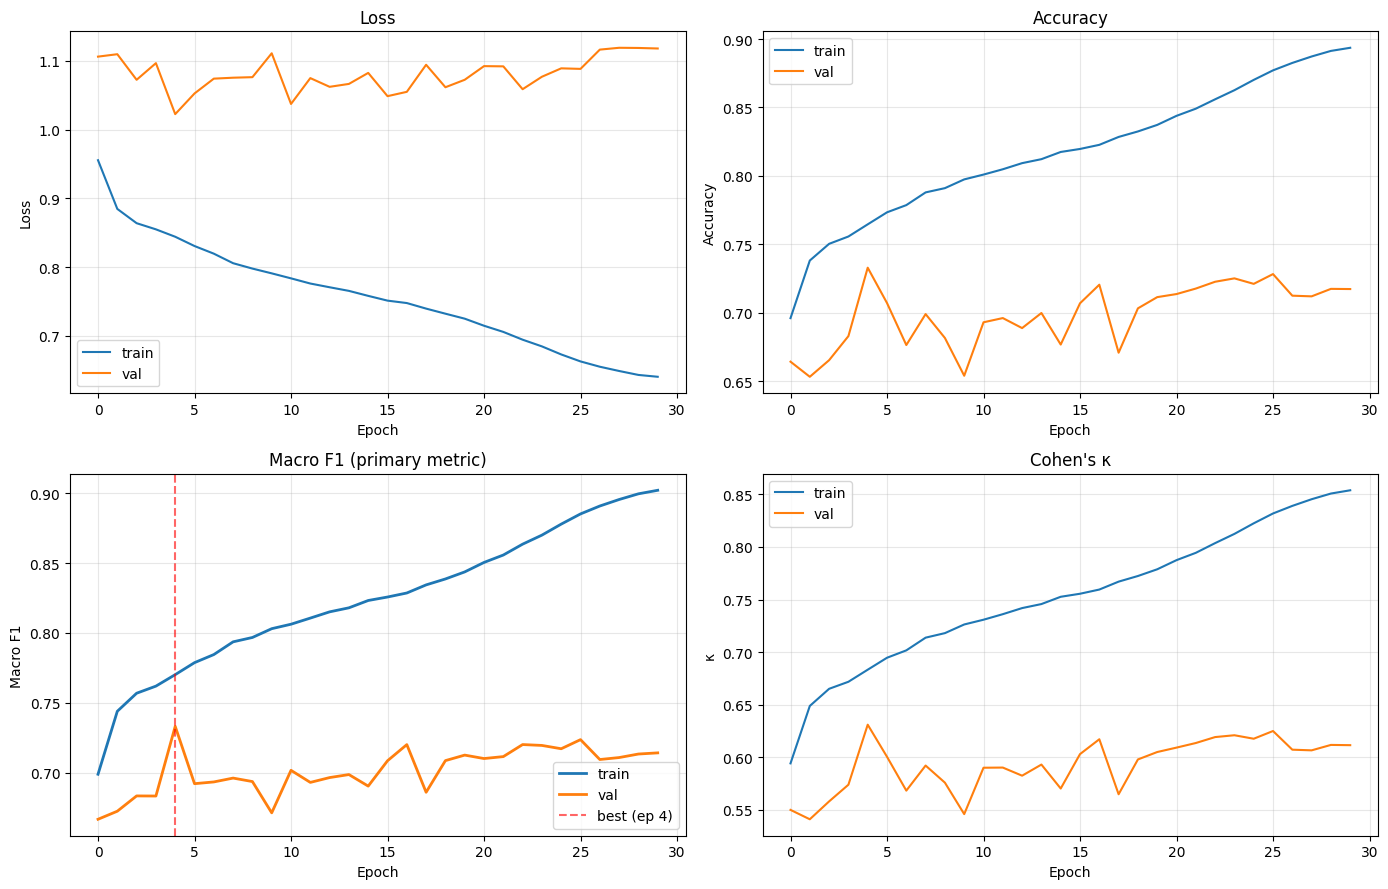

✓ Saved /content/drive/MyDrive/Sleep/checkpoints/training_curves.png


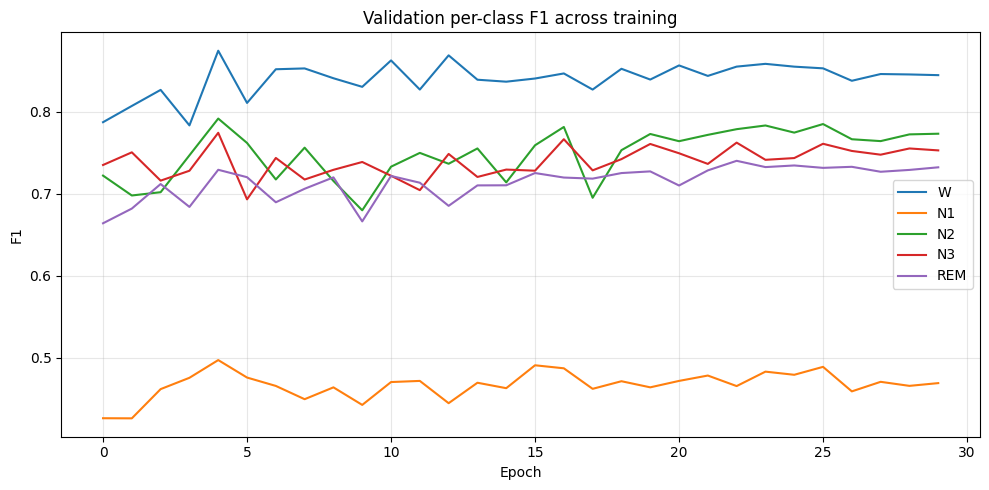

In [22]:
# =============================================================================
# CELL 9b — Training curves (Loss, Accuracy, Macro F1, Kappa)
# =============================================================================

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# ---- Loss -------------------------------------------------------------------
axes[0, 0].plot(history_df["epoch"], history_df["train_loss"], label="train")
axes[0, 0].plot(history_df["epoch"], history_df["val_loss"],   label="val")
axes[0, 0].set_title("Loss")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Loss")
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# ---- Accuracy ---------------------------------------------------------------
axes[0, 1].plot(history_df["epoch"], history_df["train_acc"], label="train")
axes[0, 1].plot(history_df["epoch"], history_df["val_acc"],   label="val")
axes[0, 1].set_title("Accuracy")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Accuracy")
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# ---- Macro F1 ---------------------------------------------------------------
axes[1, 0].plot(history_df["epoch"], history_df["train_f1_macro"],
                label="train", linewidth=2)
axes[1, 0].plot(history_df["epoch"], history_df["val_f1_macro"],
                label="val", linewidth=2)
best_epoch = int(history_df["val_f1_macro"].idxmax())
axes[1, 0].axvline(best_epoch, color="red", linestyle="--",
                   alpha=0.6, label=f"best (ep {best_epoch})")
axes[1, 0].set_title("Macro F1 (primary metric)")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Macro F1")
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# ---- Kappa ------------------------------------------------------------------
axes[1, 1].plot(history_df["epoch"], history_df["train_kappa"], label="train")
axes[1, 1].plot(history_df["epoch"], history_df["val_kappa"],   label="val")
axes[1, 1].set_title("Cohen's κ")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("κ")
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(CKPT_DIR / "training_curves.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"✓ Saved {CKPT_DIR / 'training_curves.png'}")

# ---- Per-class F1 curves ----------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 5))
for name in CLASS_NAMES:
    ax.plot(history_df["epoch"], history_df[f"val_f1_{name}"], label=name)
ax.set_title("Validation per-class F1 across training")
ax.set_xlabel("Epoch")
ax.set_ylabel("F1")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(CKPT_DIR / "per_class_f1_curves.png", dpi=120, bbox_inches="tight")
plt.show()

In [23]:
# =============================================================================
# CELL 10 — Test evaluation with best checkpoint (Macro F1 focus)
# =============================================================================

# ---- Load best checkpoint ---------------------------------------------------
ckpt = torch.load(
    CKPT_DIR / "best_model.pt",
    map_location=DEVICE,
    weights_only=False,
)
model.load_state_dict(ckpt["model_state_dict"])
best_epoch = ckpt["epoch"]

# The 'val_f1_macro' might be directly in ckpt or nested in 'val_metrics'
# We prioritize retrieving from 'val_metrics' for consistency.
if 'val_metrics' in ckpt and 'f1_macro' in ckpt['val_metrics']:
    best_val_f1_ckpt = ckpt['val_metrics']['f1_macro']
elif 'val_f1_macro' in ckpt:
    best_val_f1_ckpt = ckpt['val_f1_macro']
else:
    raise KeyError("Could not find 'val_f1_macro' in checkpoint or 'val_metrics' sub-dictionary.")

print(f"✓ Loaded best checkpoint from epoch {best_epoch} "
      f"(val Macro F1 = {best_val_f1_ckpt:.4f})")

# ---- Evaluate on test -------------------------------------------------------
test_metrics, test_labels, test_preds = evaluate(
    model, test_loader, criterion, DEVICE
)

print("\n" + "=" * 70)
print("TEST RESULTS")
print("=" * 70)
print(f"Macro F1 (primary)  : {test_metrics['f1_macro']:.4f}")
print(f"Accuracy            : {test_metrics['accuracy']:.4f}")
print(f"Cohen's κ           : {test_metrics['kappa']:.4f}")
print(f"Loss                : {test_metrics['loss']:.4f}")

print("\nPer-class F1:")
for i, name in enumerate(CLASS_NAMES):
    print(f"  {name:>4}: {test_metrics['f1_per_class'][i]:.4f}")

# ---- Confusion matrix -------------------------------------------------------
cm = confusion_matrix(test_labels, test_preds, labels=list(range(N_CLASSES)))
cm_df = pd.DataFrame(cm, index=CLASS_NAMES, columns=CLASS_NAMES)
print("\nConfusion Matrix (rows = true, cols = pred):")
print(cm_df.to_string())

cm_norm = cm.astype(float) / np.maximum(cm.sum(axis=1, keepdims=True), 1)
cm_norm_df = pd.DataFrame(cm_norm.round(3), index=CLASS_NAMES, columns=CLASS_NAMES)
print("\nNormalized Confusion Matrix (row-normalized):")
print(cm_norm_df.to_string())

# ---- Per-class precision / recall / F1 -------------------------------------
from sklearn.metrics import classification_report
report = classification_report(
    test_labels, test_preds,
    labels=list(range(N_CLASSES)),
    target_names=CLASS_NAMES,
    digits=4,
    zero_division=0,
)
print("\nClassification Report:")
print(report)

# ---- Persist results --------------------------------------------------------
results = {
    "best_epoch":        int(best_epoch),
    "val_f1_macro":      float(best_val_f1_ckpt),
    "test_f1_macro":     float(test_metrics["f1_macro"]),
    "test_accuracy":     float(test_metrics["accuracy"]),
    "test_kappa":        float(test_metrics["kappa"]),
    "test_loss":         float(test_metrics["loss"]),
    "test_f1_per_class": test_metrics["f1_per_class"].tolist(),
    "class_names":       CLASS_NAMES,
    "confusion_matrix":  cm.tolist(),
    "confusion_matrix_normalized": cm_norm.tolist(),
}
with open(CKPT_DIR / "test_results.json", "w") as f:
    json.dump(results, f, indent=2)
print(f"\n✓ Test results saved to {CKPT_DIR / 'test_results.json'}")

✓ Loaded best checkpoint from epoch 4 (val Macro F1 = 0.7332)

TEST RESULTS
Macro F1 (primary)  : 0.7740
Accuracy            : 0.7765
Cohen's κ           : 0.6955
Loss                : 0.9197

Per-class F1:
     W: 0.8901
    N1: 0.5697
    N2: 0.8182
    N3: 0.8164
   REM: 0.7756

Confusion Matrix (rows = true, cols = pred):
        W    N1    N2    N3   REM
W    1965   280     9     2    93
N1     84  1935   587    13   302
N2     11  1102  6957   668   281
N3      2    67   169  2065     0
REM     4   488   265     8  2490

Normalized Confusion Matrix (row-normalized):
         W     N1     N2     N3    REM
W    0.837  0.119  0.004  0.001  0.040
N1   0.029  0.662  0.201  0.004  0.103
N2   0.001  0.122  0.771  0.074  0.031
N3   0.001  0.029  0.073  0.897  0.000
REM  0.001  0.150  0.081  0.002  0.765

Classification Report:
              precision    recall  f1-score   support

           W     0.9511    0.8365    0.8901      2349
          N1     0.4997    0.6624    0.5697      2921


## XAI

In [24]:
# =============================================================================
# XAI-1: Setup, frequency bands, stratified sample for SHAP
# =============================================================================
import shap, json
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt, seaborn as sns

# ---- Reload best model ----
ckpt = torch.load(CKPT_DIR / "best_model.pt", map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()
print(f"Loaded best model (epoch {ckpt['epoch']}, val F1={ckpt['val_f1_macro']:.4f})")

# ---- Frequency axis & physiological bands ----
FREQS = np.linspace(0.0, SFREQ / 2, F_BINS)   # 0..50 Hz, 129 bins
BANDS = {
    "δ 0.5-4Hz":  (0.5, 4.0),
    "θ 4-8Hz":    (4.0, 8.0),
    "α 8-12Hz":   (8.0, 12.0),
    "σ 12-16Hz":  (12.0, 16.0),
    "β 16-30Hz":  (16.0, 30.0),
    "γ 30-50Hz":  (30.0, 50.0),
}
BAND_SLICES = {k: np.where((FREQS >= lo) & (FREQS < hi))[0]
               for k, (lo, hi) in BANDS.items()}
print("Band bin counts:", {k: len(v) for k, v in BAND_SLICES.items()})

# ---- Stratified sample from test set ----
N_SHAP       = 300     # total SHAP-explained epochs (60 per class)
N_BACKGROUND = 30      # reference samples for GradientExplainer

rng = np.random.default_rng(0)
y_test_all = test_ds._labels[0]
idx_by_class = {c: np.where(y_test_all == c)[0] for c in range(N_CLASSES)}
per_class = N_SHAP // N_CLASSES
sample_idx = np.concatenate([
    rng.choice(idx_by_class[c], size=per_class, replace=False) for c in range(N_CLASSES)
])
rng.shuffle(sample_idx)

X_shap = torch.stack([test_ds[i][0] for i in sample_idx]).to(DEVICE)   # (N,3,22,129)
y_shap = y_test_all[sample_idx]
print(f"\nSHAP sample: X={tuple(X_shap.shape)}  y-dist={np.bincount(y_shap).tolist()}")

# ---- Background from train set ----
bg_idx = rng.choice(len(train_ds), size=N_BACKGROUND, replace=False)
background = torch.stack([train_ds[i][0] for i in bg_idx]).to(DEVICE)
print(f"Background: {tuple(background.shape)}")

Loaded best model (epoch 4, val F1=0.7332)
Band bin counts: {'δ 0.5-4Hz': 9, 'θ 4-8Hz': 10, 'α 8-12Hz': 10, 'σ 12-16Hz': 10, 'β 16-30Hz': 36, 'γ 30-50Hz': 51}

SHAP sample: X=(300, 3, 22, 129)  y-dist=[60, 60, 60, 60, 60]
Background: (30, 3, 22, 129)


In [25]:
# =============================================================================
# XAI-2: Compute SHAP values (GradientExplainer)
# =============================================================================
class ProbWrapper(torch.nn.Module):
    """Wrap model so SHAP explains softmax probabilities per class."""
    def __init__(self, m): super().__init__(); self.m = m
    def forward(self, x): return torch.softmax(self.m(x), dim=-1)

wrapped = ProbWrapper(model).eval()

explainer = shap.GradientExplainer(wrapped, background)
shap_out = explainer.shap_values(X_shap, nsamples=80)

# Normalize to (C=5, N, Ch=3, T=22, F=129)
if isinstance(shap_out, list):
    sv = np.stack(shap_out, axis=0)
else:
    sv = np.transpose(shap_out, (4, 0, 1, 2, 3))     # (N,3,22,129,5) -> (5,N,3,22,129)

print("SHAP tensor:", sv.shape)
np.save(CKPT_DIR / "shap_values.npy", sv)
np.save(CKPT_DIR / "shap_y.npy", y_shap)
print(f"✓ Saved to {CKPT_DIR}/shap_values.npy")

SHAP tensor: (5, 300, 3, 22, 129)
✓ Saved to /content/drive/MyDrive/Sleep/checkpoints/shap_values.npy


Loaded best model (epoch 4, val F1=0.7332)
Band bin counts: {'δ 0.5-4Hz': 9, 'θ 4-8Hz': 10, 'α 8-12Hz': 10, 'σ 12-16Hz': 10, 'β 16-30Hz': 36, 'γ 30-50Hz': 51}

SHAP sample: X=(300, 3, 22, 129)  y-dist=[60, 60, 60, 60, 60]
Background: (30, 3, 22, 129)


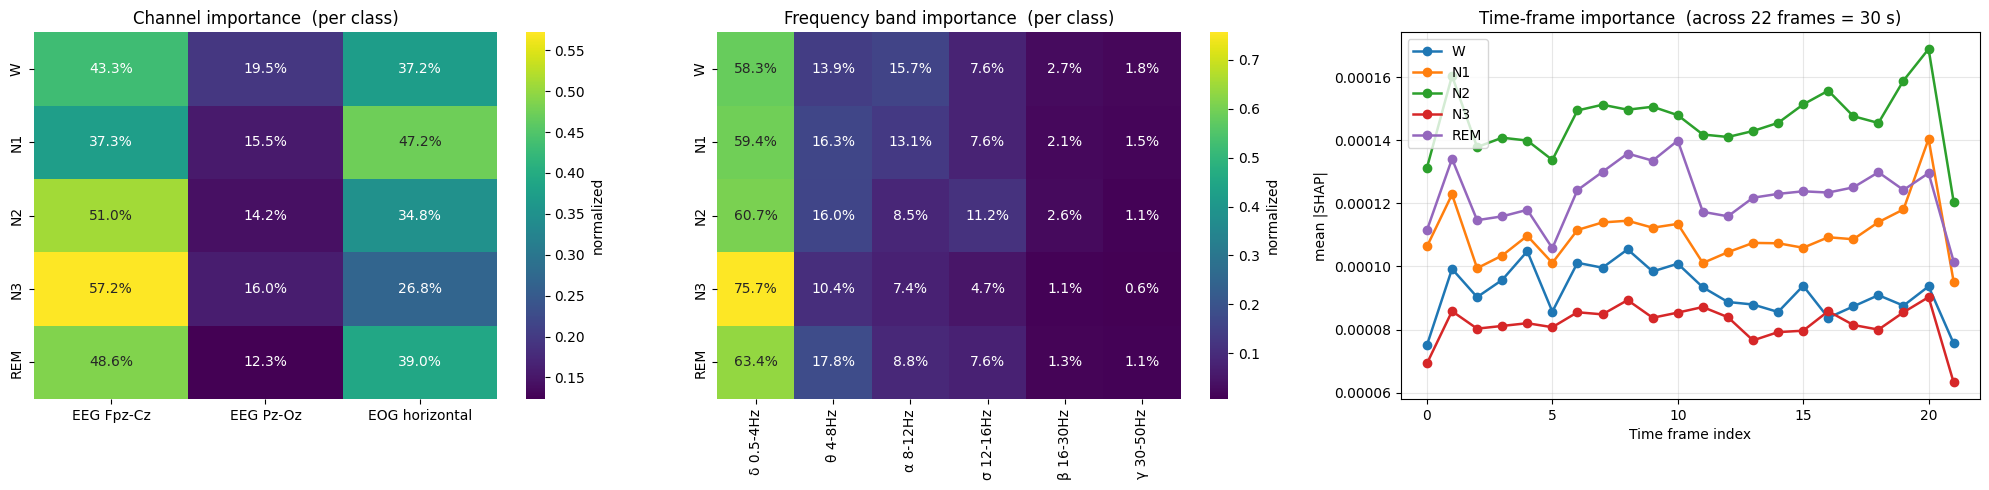

✓ Saved /content/drive/MyDrive/Sleep/checkpoints/shap_global.png


In [27]:
import shap, json
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt, seaborn as sns

# ---- Reload best model ----
ckpt = torch.load(CKPT_DIR / "best_model.pt", map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()
print(f"Loaded best model (epoch {ckpt['epoch']}, val F1={ckpt['val_f1_macro']:.4f})")

# ---- Frequency axis & physiological bands ----
FREQS = np.linspace(0.0, SFREQ / 2, F_BINS)   # 0..50 Hz, 129 bins
BANDS = {
    "δ 0.5-4Hz":  (0.5, 4.0),
    "θ 4-8Hz":    (4.0, 8.0),
    "α 8-12Hz":   (8.0, 12.0),
    "σ 12-16Hz":  (12.0, 16.0),
    "β 16-30Hz":  (16.0, 30.0),
    "γ 30-50Hz":  (30.0, 50.0),
}
BAND_SLICES = {k: np.where((FREQS >= lo) & (FREQS < hi))[0]
               for k, (lo, hi) in BANDS.items()}
print("Band bin counts:", {k: len(v) for k, v in BAND_SLICES.items()})

# ---- Stratified sample from test set ----
N_SHAP       = 300     # total SHAP-explained epochs (60 per class)
N_BACKGROUND = 30      # reference samples for GradientExplainer

rng = np.random.default_rng(0)
y_test_all = test_ds._labels[0]
idx_by_class = {c: np.where(y_test_all == c)[0] for c in range(N_CLASSES)}
per_class = N_SHAP // N_CLASSES
sample_idx = np.concatenate([
    rng.choice(idx_by_class[c], size=per_class, replace=False) for c in range(N_CLASSES)
])
rng.shuffle(sample_idx)

X_shap = torch.stack([test_ds[i][0] for i in sample_idx]).to(DEVICE)   # (N,3,22,129)
y_shap = y_test_all[sample_idx]
print(f"\nSHAP sample: X={tuple(X_shap.shape)}  y-dist={np.bincount(y_shap).tolist()}")

# ---- Background from train set ----
bg_idx = rng.choice(len(train_ds), size=N_BACKGROUND, replace=False)
background = torch.stack([train_ds[i][0] for i in bg_idx]).to(DEVICE)
print(f"Background: {tuple(background.shape)}")
# =============================================================================
# XAI-3: Aggregated global analyses
# =============================================================================
def channel_imp(sv):  return np.abs(sv).mean(axis=(1, 3, 4))            # (5,3)
def band_imp(sv):
    out = np.zeros((sv.shape[0], len(BAND_SLICES)))
    for i, sl in enumerate(BAND_SLICES.values()):
        out[:, i] = np.abs(sv[:, :, :, :, sl]).mean(axis=(1, 2, 3, 4)) # <--- FIX: Added axis=4
    return out                                                          # (5,B)
def time_imp(sv):     return np.abs(sv).mean(axis=(1, 2, 4))            # (5,22)

ch_imp   = channel_imp(sv)
bd_imp   = band_imp(sv)
tm_imp   = time_imp(sv)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

sns.heatmap(ch_imp / ch_imp.sum(1, keepdims=True), annot=True, fmt=".1%",
            xticklabels=KEEP_CHANNELS, yticklabels=CLASS_NAMES,
            cmap="viridis", ax=axes[0], cbar_kws={"label": "normalized"})
axes[0].set_title("Channel importance  (per class)")

sns.heatmap(bd_imp / bd_imp.sum(1, keepdims=True), annot=True, fmt=".1%",
            xticklabels=list(BAND_SLICES), yticklabels=CLASS_NAMES,
            cmap="viridis", ax=axes[1], cbar_kws={"label": "normalized"})
axes[1].set_title("Frequency band importance  (per class)")

for c, name in enumerate(CLASS_NAMES):
    axes[2].plot(tm_imp[c], marker="o", label=name, linewidth=1.8)
axes[2].set_title("Time-frame importance  (across 22 frames = 30 s)")
axes[2].set_xlabel("Time frame index"); axes[2].set_ylabel("mean |SHAP|")
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(CKPT_DIR / "shap_global.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"✓ Saved {CKPT_DIR/'shap_global.png'}")


/tmp/ipykernel_680/2436049358.py:18: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


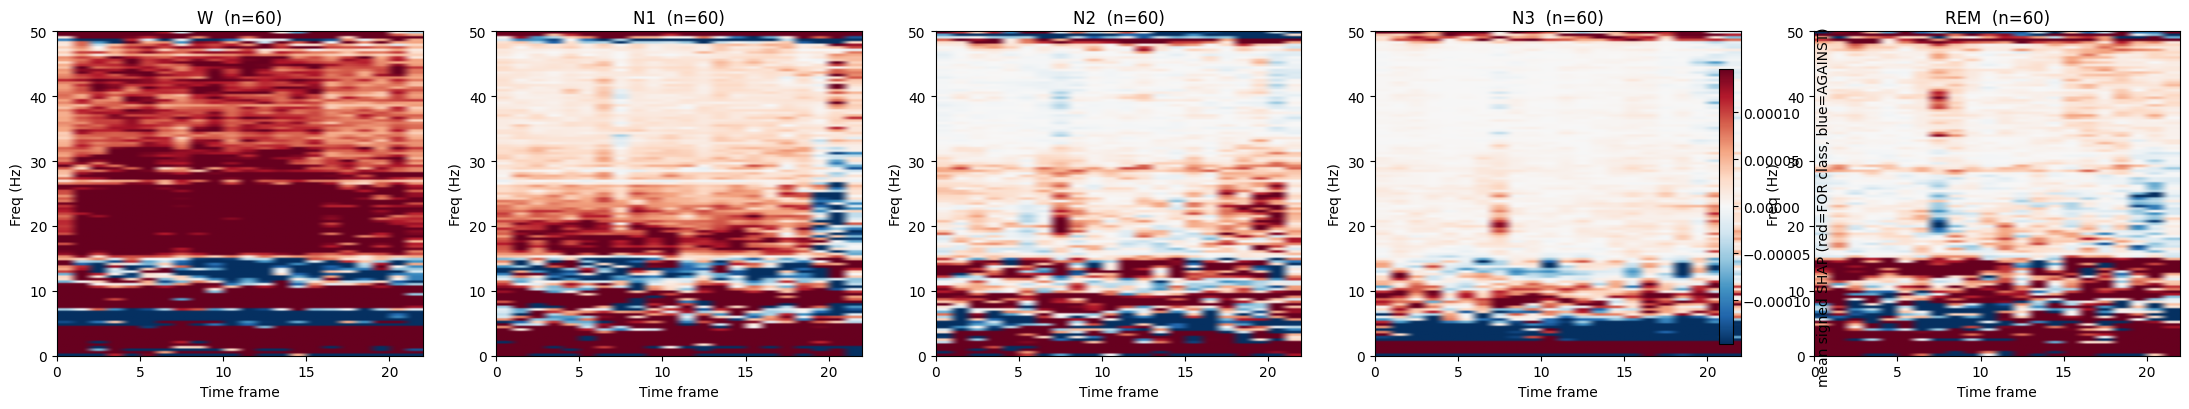

✓ Saved /content/drive/MyDrive/Sleep/checkpoints/shap_tf_maps.png


In [28]:
# =============================================================================
# XAI-4: Signed SHAP maps per class  (what TF cells vote FOR each class)
# =============================================================================
fig, axes = plt.subplots(1, N_CLASSES, figsize=(22, 4.2))
vmax = np.abs(sv).mean(axis=(1,2,3,4)).max()   # shared scale across classes
im = None
for c, name in enumerate(CLASS_NAMES):
    mask = y_shap == c
    m = sv[c, mask].mean(axis=0).sum(axis=0)   # (22,129)  sum over channels
    im = axes[c].imshow(m.T, aspect="auto", origin="lower",
                        cmap="RdBu_r", vmin=-vmax, vmax=vmax,
                        extent=[0, 22, 0, SFREQ/2])
    axes[c].set_title(f"{name}  (n={mask.sum()})")
    axes[c].set_xlabel("Time frame"); axes[c].set_ylabel("Freq (Hz)")

fig.colorbar(im, ax=axes, label="mean signed SHAP (red=FOR class, blue=AGAINST)",
             shrink=0.85)
plt.tight_layout()
plt.savefig(CKPT_DIR / "shap_tf_maps.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"✓ Saved {CKPT_DIR/'shap_tf_maps.png'}")

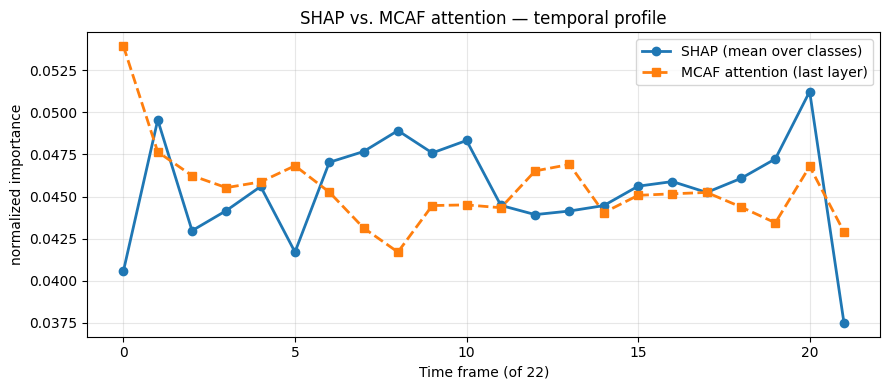

Pearson r(SHAP-time, attention-time) = -0.258
⚠ Attention and SHAP disagree — attention alone is not reliable XAI.


In [29]:
# =============================================================================
# XAI-5: Do attention weights agree with SHAP?
# =============================================================================
with torch.no_grad():
    _, attn_list = model(X_shap, return_attention=True)

# Last MCAF layer attention: (N,H,66,66) -> key importance per time frame
last = attn_list[-1]                              # (N,H,C*T,C*T)
H = last.shape[1]
key_imp = last.mean(dim=1).sum(dim=1)             # (N, C*T)
key_imp = key_imp.reshape(X_shap.shape[0], N_CHANNELS, T_FREQ).mean(dim=1)
attn_time = key_imp.cpu().numpy().mean(axis=0)    # (22,)

shap_time = tm_imp.mean(axis=0)                   # (22,) mean over classes

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(shap_time / shap_time.sum(), "-o",  label="SHAP (mean over classes)", lw=2)
ax.plot(attn_time / attn_time.sum(), "--s", label="MCAF attention (last layer)", lw=2)
ax.set_xlabel("Time frame (of 22)"); ax.set_ylabel("normalized importance")
ax.set_title("SHAP vs. MCAF attention — temporal profile")
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout()
plt.savefig(CKPT_DIR / "shap_vs_attention.png", dpi=120, bbox_inches="tight")
plt.show()

r = float(np.corrcoef(shap_time, attn_time)[0, 1])
print(f"Pearson r(SHAP-time, attention-time) = {r:+.3f}")
if r > 0.6:   print("✓ Attention mechanism is consistent with SHAP.")
elif r > 0.3: print("~ Moderate agreement — attention is only partly faithful.")
else:         print("⚠ Attention and SHAP disagree — attention alone is not reliable XAI.")

In [30]:
# =============================================================================
# XAI-6: Automatic findings + JSON export
# =============================================================================
ch_pct = ch_imp / ch_imp.sum(1, keepdims=True)
bd_pct = bd_imp / bd_imp.sum(1, keepdims=True)

findings = {}
print("=" * 78)
print("SHAP FINDINGS — physiological plausibility check")
print("=" * 78)

EXPECTED = {
    # class -> (expected dominant band, expected strongest channel)
    "W":   ("α 8-12Hz",  "EEG"),
    "N1":  ("θ 4-8Hz",   "EEG"),
    "N2":  ("σ 12-16Hz", "EEG"),
    "N3":  ("δ 0.5-4Hz", "EEG"),
    "REM": ("θ 4-8Hz",   "EOG"),
}
for c, name in enumerate(CLASS_NAMES):
    top_ch   = KEEP_CHANNELS[int(np.argmax(ch_pct[c]))]
    top_band = list(BAND_SLICES)[int(np.argmax(bd_pct[c]))]
    exp_band, exp_ch = EXPECTED[name]
    ok_band = exp_band.split()[0] in top_band
    ok_ch   = (exp_ch == "EOG" and "EOG" in top_ch) or \
              (exp_ch == "EEG" and "EEG" in top_ch)
    print(f"\n{name:>4}  (n={int((y_shap==c).sum())})")
    print(f"    dominant channel : {top_ch:18s}  [{ch_pct[c].max():.1%}]"
          f"   expected ~{exp_ch}  {'✓' if ok_ch else '✗'}")
    print(f"    dominant band    : {top_band:14s}  [{bd_pct[c].max():.1%}]"
          f"   expected ~{exp_band}  {'✓' if ok_band else '✗'}")
    findings[name] = {
        "dominant_channel": top_ch, "channel_share": float(ch_pct[c].max()),
        "dominant_band":    top_band, "band_share":  float(bd_pct[c].max()),
        "band_profile": {k: float(v) for k, v in zip(BAND_SLICES, bd_pct[c])},
        "channel_profile": {k: float(v) for k, v in zip(KEEP_CHANNELS, ch_pct[c])},
        "band_physio_ok": bool(ok_band), "channel_physio_ok": bool(ok_ch),
    }

n_ok = sum(int(f["band_physio_ok"]) for f in findings.values())
print(f"\nPhysiological band agreement: {n_ok}/5 classes")
print(f"SHAP–attention time correlation: r = {r:+.3f}")

with open(CKPT_DIR / "shap_findings.json", "w") as f:
    json.dump({"findings": findings, "shap_attention_corr": r,
               "n_shap_samples": int(X_shap.shape[0])}, f, indent=2)
print(f"\n✓ Saved {CKPT_DIR/'shap_findings.json'}")

SHAP FINDINGS — physiological plausibility check

   W  (n=60)
    dominant channel : EEG Fpz-Cz          [43.3%]   expected ~EEG  ✓
    dominant band    : δ 0.5-4Hz       [58.3%]   expected ~α 8-12Hz  ✗

  N1  (n=60)
    dominant channel : EOG horizontal      [47.2%]   expected ~EEG  ✗
    dominant band    : δ 0.5-4Hz       [59.4%]   expected ~θ 4-8Hz  ✗

  N2  (n=60)
    dominant channel : EEG Fpz-Cz          [51.0%]   expected ~EEG  ✓
    dominant band    : δ 0.5-4Hz       [60.7%]   expected ~σ 12-16Hz  ✗

  N3  (n=60)
    dominant channel : EEG Fpz-Cz          [57.2%]   expected ~EEG  ✓
    dominant band    : δ 0.5-4Hz       [75.7%]   expected ~δ 0.5-4Hz  ✓

 REM  (n=60)
    dominant channel : EEG Fpz-Cz          [48.6%]   expected ~EOG  ✗
    dominant band    : δ 0.5-4Hz       [63.4%]   expected ~θ 4-8Hz  ✗

Physiological band agreement: 1/5 classes
SHAP–attention time correlation: r = -0.258

✓ Saved /content/drive/MyDrive/Sleep/checkpoints/shap_findings.json
